## Fitting with 2018 CLAS XLUw dataset

In [31]:
import os
import sys
import gepard as g # NeuralModel with Dispersion relation added 
from gepard import model, fitter, data, plots
import gepard.plots as gplot
from gepard.fits import GLO15new, AUTIpts, ALUIpts, ACpts, AULpts, ALLpts, H1ZEUS, CLAS08pts
print('Gepard version = {}'.format(g.__version__))

Gepard version = 0.9.11b0


In [32]:
import gmaster as gm
from gmaster.fits import th_KM15, th_KM10b, par_KM15, par_KM15 # need KM15 for simulated data
th15 = th_KM15
from gmaster.constants import Mp2, toTeX

In [33]:
import torch
import numpy as np 
#np.set_printoptions(legacy='1.25')
import matplotlib
import matplotlib.pyplot as plt
import shelve, logging, copy
logging.basicConfig(level=logging.ERROR) 
import pandas as pd 
from scipy.integrate import quad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.stats import norm

### To add our data files to gepard

In [34]:
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')

import mydatafiles
from mydatafiles import ep2epgamma

mydset = g.data.loaddata(mydatafiles)
mydset.update(g.data.loaddata(ep2epgamma))

In [35]:
# To have nice LaTeX fonts on plots
plt.rc('text', usetex=False)
params = {'text.latex.preamble' : '\n'.join([r'\usepackage{amssymb}', r'\usepackage{amsmath}'])}
plt.rcParams.update(params)

In [36]:
class KM15(gm.eff.KellyEFF, gm.gpd.PWNormGPD, gm.cff.HybridFreePoleCFF, gm.dvcs.BM10tw2):

    pass

th_KM15_H = KM15()
th_KM15_H.parameters.update(par_KM15)
th_KM15_H.parameters.update({'trv':0, 'rpi':0})
th_KM15_H.name = 'KM15_H'

In [37]:
HallA15_XLUw = g.dset.get(117,[])
HallA15w = g.dset.get(117,[]) + g.dset.get(116,[])[:15] + g.dset.get(116,[])[15:] # 2015(BSDw+BSSw)
HallA17w = g.dset.get(135,[]) + g.dset.get(136,[])[:22] + g.dset.get(136,[])[22:] # 2017(BSDw+BSSw)
HallA6w = g.dset.get(50, []) + g.dset.get(51, []) + g.dset.get(105, []) # 2006(BSDw_byDM+BSSw+BSDovBSS)

CLAS18XUUw = g.select(mydset.get(162, []), criteria=['FTn == 0']) + g.select(mydset.get(162, []), criteria=['FTn == 1']) + g.select(mydset.get(162, []), criteria=['FTn == 2'])
#CLAS18XLU = mydset.get(164, [])
CLAS18XLU = mydset.get(165, [])
CLAS18 = CLAS18XUUw + CLAS18XLU

CLAS25XUU = g.select(mydset.get(167, []), criteria=['FTn == 0']) + g.select(mydset.get(167, []), criteria=['FTn == 1']) + g.select(mydset.get(167, []), criteria=['FTn == 2'])

In [38]:
fitpoints = (
    g.dset.get(101, []) + g.dset.get(102, []) #+ g.dset.get(8, [])  
    #+ g.dset.get(81, []) + g.dset.get(94, []) + g.dset.get(95, []) + g.dset.get(96, [])
    #+ mydset.get(150, []) # BSA 2023 CLAS
    #+ CLAS18XLU  # + mydset.get(182, []) + mydset.get(192, []) 
    #+ ACpts+ AULpts + ALLpts  # HERMES
    # HallA6w  # 2006(BSDw_byDM+BSSw+BSDovBSS)
    # g.dset.get(117, []) + g.dset.get(116, []) + g.dset.get(135, []) + g.dset.get(136, []) + g.dset.get(145, []) # 2015(BSDw+BSSw), 2017(BSDw+BSSw+X)  ##HallA
    # HallA15_XLUw + HallA15w + HallA17w
)   
g.describe_data(fitpoints)

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
48 x XLUw    CLAS    -1     101 arXiv:1504.02009
48 x XUUw    CLAS    0.0    102 arXiv:1504.02009
48 x XUUw    CLAS    1.0    102 arXiv:1504.02009
----------------------------------------------
TOTAL = 144


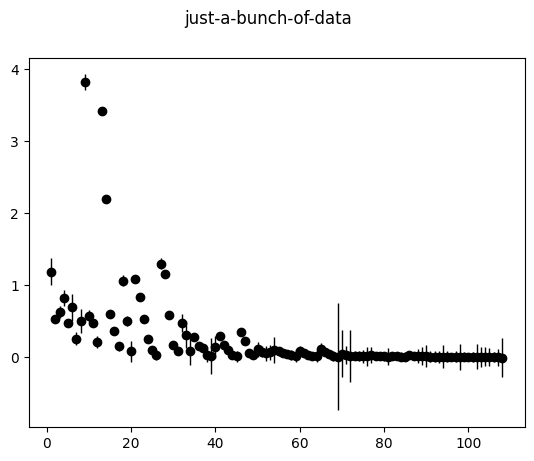

In [39]:
fig = gplot.jbod(points=g.select(mydset.get(168, []), criteria=['FTn == 0']))

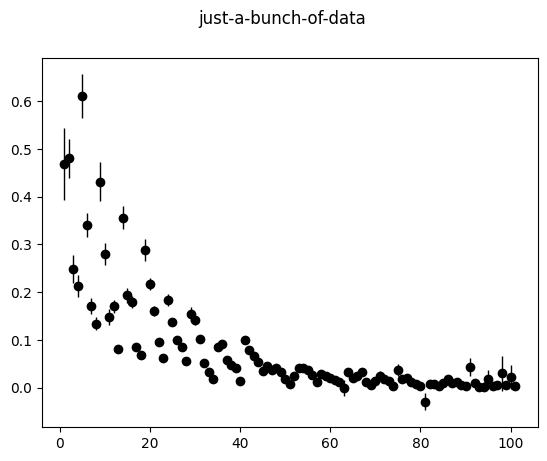

In [40]:
fig = gplot.jbod(points=g.select(mydset.get(165, []), criteria=['FTn == -1']))

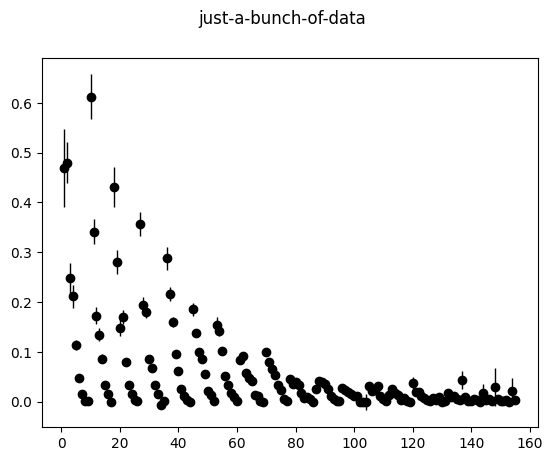

In [41]:
fig = gplot.jbod(points=g.select(mydset.get(164, [])))

In [42]:
data = mydset[150]
BSA = data.df()   # ALU by CLAS 2022
data = mydset[162]
BSS = data.df()  # CLAS 2018
data = mydset[164]
BSD = data.df()  # CLAS 2015

In [43]:
# Bins can be defined as ranges within the following limiting values:
tmlims = [0, 0.13, 0.18, 0.22, 0.3, 0.4, 0.5, 0.7]
xilims = [0, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21, 0.23, 0.26, 0.29, 0.32]  

Text(0, 0.5, '$-t\\quad[{\\rm GeV}^2]$')

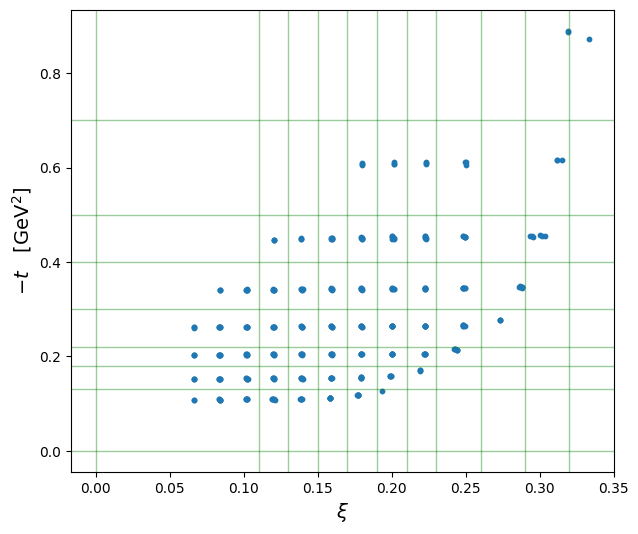

In [44]:
fig, ax = plt.subplots(figsize=[7,6])
ax.scatter(BSS.xi, BSS.tm, s=10)
for tm in tmlims:
    ax.axhline(tm, color='g', linewidth=1, alpha=0.4)
for xi in xilims:
    ax.axvline(xi, color='g', linewidth=1, alpha=0.4)
ax.set_xlabel(r'$\xi$', fontsize=14)
ax.set_ylabel(r'$-t\quad[{\rm GeV}^2]$', fontsize=14)

Text(0, 0.5, '$-t\\quad[{\\rm GeV}^2]$')

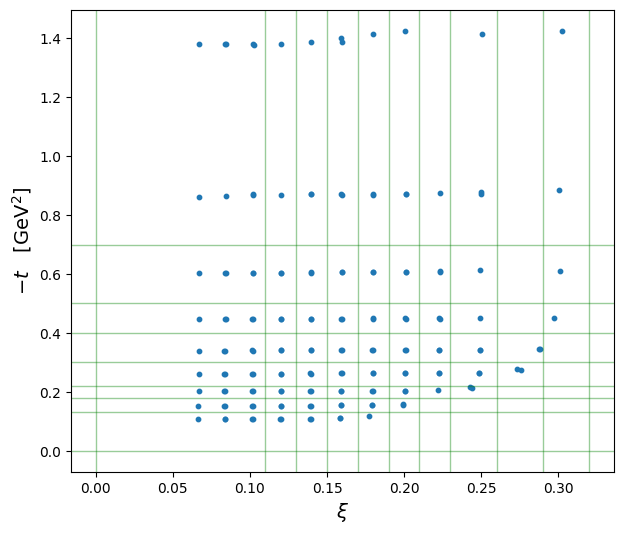

In [45]:
fig, ax = plt.subplots(figsize=[7,6])
ax.scatter(BSD.xi, BSD.tm, s=10)
for tm in tmlims:
    ax.axhline(tm, color='g', linewidth=1, alpha=0.4)
for xi in xilims:
    ax.axvline(xi, color='g', linewidth=1, alpha=0.4)
ax.set_xlabel(r'$\xi$', fontsize=14)
ax.set_ylabel(r'$-t\quad[{\rm GeV}^2]$', fontsize=14)

## Fit with NeuralModel

In [46]:
class NNTest(g.model.NeuralModel, g.eff.DipoleEFF, g.dvcs.BM10tw2):    

    def build_net(self):
            '''Overriding the default architecture and optimizer'''
            nn_model = torch.nn.Sequential(
                    torch.nn.Linear(3, 23),
                    torch.nn.ReLU(),
                    torch.nn.Linear(23, 37),
                    torch.nn.ReLU(),
                    torch.nn.Linear(37, 19),
                    torch.nn.ReLU(),
                    torch.nn.Linear(19, len(self.output_layer))
                )
            optimizer = torch.optim.Rprop(nn_model.parameters(), lr=0.01 ) #lr=0.05 #2e-3
            return nn_model, optimizer

In [47]:
th = NNTest(output_layer=['ImH', 'ReH'], q2in=True)  
print(th.useDR)

None


In [48]:
f = g.fitter.NeuralFitter(fitpoints, th, nnets=10, nbatch=10, batchlen=3, regularization='L2', lx_lambda=0.01)
f.fit()


Epoch   3: train error = 4.3686 test error = 4.0109 -
Epoch   6: train error = 2.6668 test error = 1.7524 -
Epoch   9: train error = 1.7334 test error = 1.4629 -
Epoch  12: train error = 1.6042 test error = 1.5877 +
Epoch  15: train error = 1.4854 test error = 1.4177 -
Epoch  18: train error = 1.4261 test error = 1.3901 -
Epoch  21: train error = 1.3888 test error = 1.3718 -
Epoch  24: train error = 1.3455 test error = 1.3291 -
Epoch  27: train error = 1.3059 test error = 1.3179 -
Epoch  30: train error = 1.2737 test error = 1.2937 -Net 0 --> test_err = 1.2936574705840025

Epoch   3: train error = 4.3053 test error = 4.5560 -
Epoch   6: train error = 2.6318 test error = 2.8955 -
Epoch   9: train error = 1.3494 test error = 1.9697 -
Epoch  12: train error = 1.1320 test error = 1.4068 -
Epoch  15: train error = 1.0964 test error = 1.4511 +
Epoch  18: train error = 1.0703 test error = 1.3529 -
Epoch  21: train error = 1.0534 test error = 1.3438 -
Epoch  24: train error = 1.0321 test erro

In [49]:
th.chisq(fitpoints)

(np.float64(35.24096163294086), 144, np.float64(1.0))

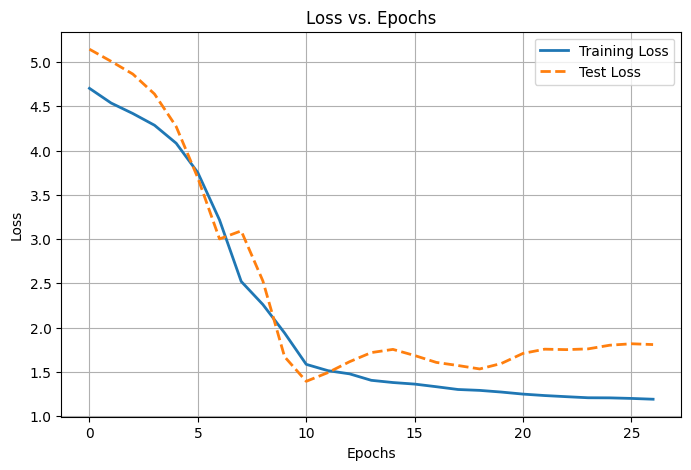

In [50]:
# Plot the results:
plt.figure(figsize=(8, 5))
plt.plot(f.history, label="Training Loss",linewidth=2.0)
plt.plot(f.test_history, label="Test Loss", linestyle="dashed",linewidth=2.0)
plt.xlabel("Epochs") #Epochs in nbatch length
plt.ylabel("Loss")
plt.title("Loss vs. Epochs")
plt.legend()
plt.grid()
plt.show()

### Just a bunch of data with mydataset

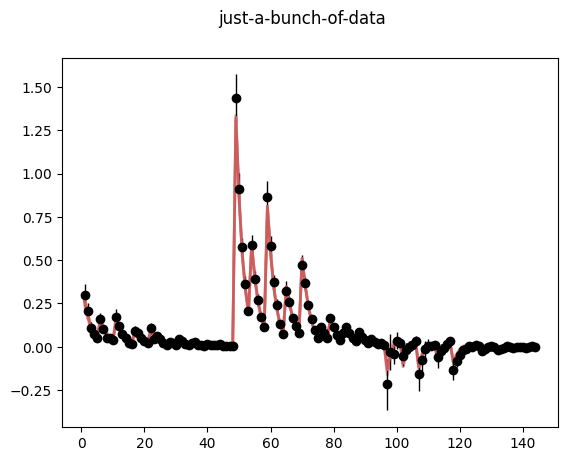

In [51]:
fig = gplot.jbod(points=fitpoints, lines=[th], bands=[th])

### CFFs plots in the no DR case

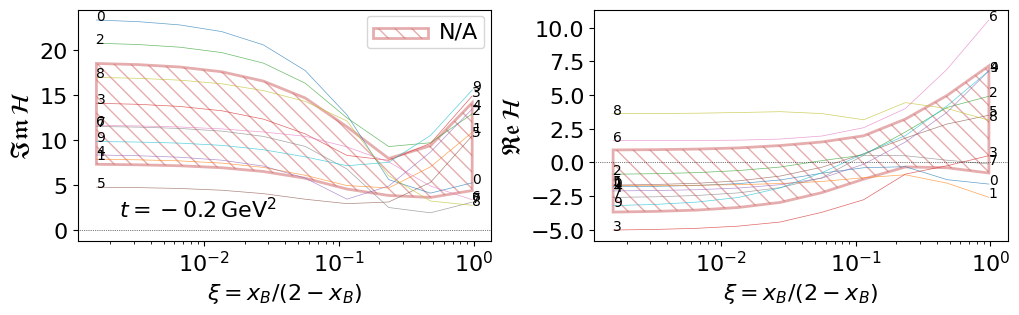

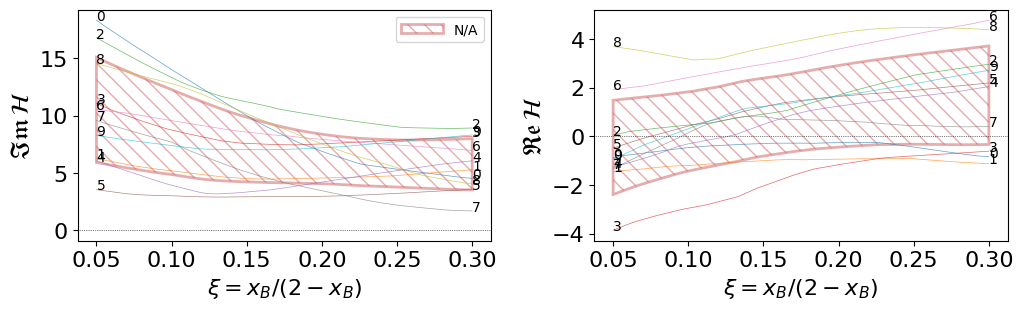

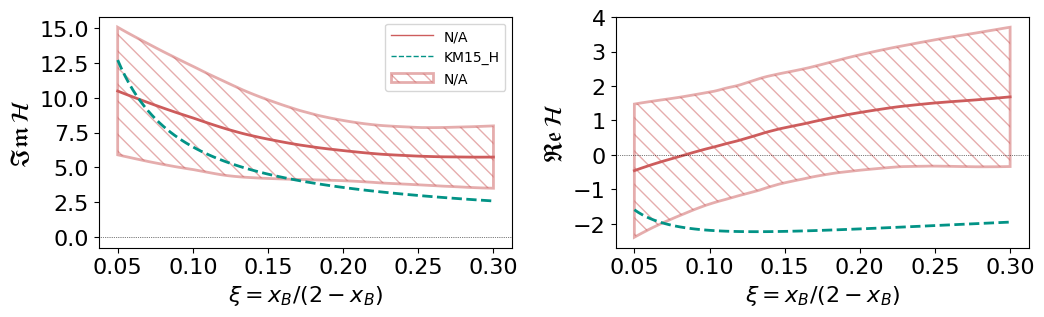

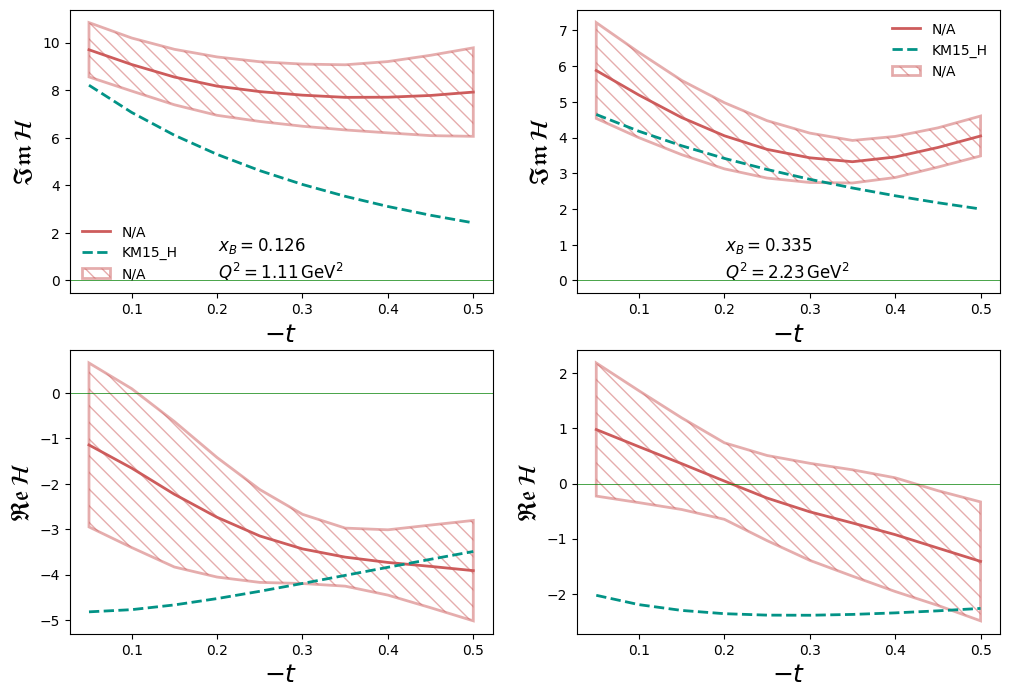

In [52]:
fig = gplot.CFF3log(cffs=['ImH', 'ReH'],  mesh=th, bands=[th], tval=-0.2)
fig = gplot.CFF3(cffs=['ImH', 'ReH'],  mesh=th, bands=[th])
fig = gplot.CFF3(cffs=['ImH', 'ReH'],  lines=[th, th_KM15_H], bands=[th])
fig = gplot.CFFt(cffs=['ImH', 'ReH'],  lines=[th, th_KM15_H], bands=[th])

## Custom NN

In [53]:
import torch.nn as nn
class CustomNetwork(nn.Module):
    def __init__(self):
        super(CustomNetwork, self).__init__()

        # Define the layers for the network
        self.n1 = nn.Linear(3, 23)  # 2 input features, 12 hidden units
        self.n2 = nn.Linear(23, 37)  # 12 hidden units, 17 hidden units
        self.n3 = nn.Linear(37, 1)  # 7 hidden units, 1 output features
        
        self.n1p = nn.Linear(1, 7)  # 2 input features, 12 hidden units
        self.n2p = nn.Linear(7, 5)  # 12 hidden units, 17 hidden units
        self.n3p = nn.Linear(5, 1)  # 17 hidden units, 1 output features

    def forward(self, x):
        
       
        x0 = x
        
        # Build Im network
        x = torch.relu(self.n1(x0))
        x = torch.relu(self.n2(x))
        output1 = self.n3(x)
        
        # Build D network
        # build the input tensor
        x0_1 = torch.cat((x0[:,1].unsqueeze(1),), dim=0)
       
        x2 = torch.relu(self.n1p(x0_1))
        x2 = torch.relu(self.n2p(x2))
        output2 = self.n3p(x2)
        
        #concatenate outputs
        output = torch.cat((output1, output2), dim=1)
       
        return output 

### Create the class inheriting from DispersionCFF

In [54]:
class NNTest_DR(g.model.NeuralModel_DR, g.eff.DipoleEFF, g.dvcs.BM10tw2, g.cff.DispersionCFF):
    
    def build_net(self):
        '''Overriding the default architecture and optimizer'''
        nn_model = CustomNetwork()
        optimizer = torch.optim.Rprop(nn_model.parameters(),
                lr=0.01)
        return nn_model, optimizer
    
    def subtraction(self, pt): #This should use the NN, the real part will be calculated by the CFF_Dispersion methods
        """Subtraction constant."""
        #refer to the location of D in output layer (defined in the next cell)
        xi = pt.xB / (2 - pt.xB)
        return self.cffs(1, pt, xi)
    
    def ImH(self, pt, xi=0) -> float:
        """Return Im(CFF H) for kinematic point."""
        #refer to the location of Im H in output layer (defined in the next cell)
        return self.cffs(0, pt, xi)
    
    def ImE(self, pt, xi=0):
        """Return Im(CFF E) for kinematic point."""
        return self.zero(pt)
    
    def ImHt(self, pt, xi=0):
        """Return Im(CFF Ht) for kinematic point."""
        return self.zero(pt)
    
    def ImEt(self, pt, xi=0):
        """Return Im(CFF Et) for kinematic point."""
        return self.zero(pt)

In [55]:
th2 = NNTest_DR(output_layer=['ImH', 'D'], q2in=True)

In [56]:
import time
t0 = time.time()

f = g.fitter.NeuralFitter(fitpoints, th2, nnets=5, nbatch=10, batchlen=3, regularization='L2', lx_lambda=0.01)
#f = g.fitter.NeuralFitter(fitpoints, th2, nnets=3, nbatch=10, batchlen=4, regularization='L1', lx_lambda=0.001)
#f = g.fitter.NeuralFitter(fitpoints, th2, nnets=5, batchlen=10, regularization='L2', lx_lambda=0.002)
f.fit()
#torch.save(th2.nets, 'Test_dataset2_nets.tar')

t1 = time.time()
# time in minutes
print(f"Total time: {(t1 - t0) / 60:.2f} minutes")


Epoch   3: train error = 4.5334 test error = 4.4096 -
Epoch   6: train error = 3.5878 test error = 3.3427 -
Epoch   9: train error = 2.0270 test error = 1.9834 -
Epoch  12: train error = 1.6519 test error = 1.7195 -
Epoch  15: train error = 1.5086 test error = 1.5814 -
Epoch  18: train error = 1.4298 test error = 1.5270 -
Epoch  21: train error = 1.3907 test error = 1.4860 -
Epoch  24: train error = 1.3582 test error = 1.4590 -
Epoch  27: train error = 1.3230 test error = 1.4578 -
Epoch  30: train error = 1.2960 test error = 1.4329 -Net 0 --> test_err = 1.4329490644896739

Epoch   3: train error = 4.5447 test error = 2.9379 -
Epoch   6: train error = 3.2687 test error = 2.1632 -
Epoch   9: train error = 1.4372 test error = 1.8936 -
Epoch  12: train error = 1.4178 test error = 1.6333 -
Epoch  15: train error = 1.3153 test error = 1.7002 +
Epoch  18: train error = 1.2888 test error = 1.6841 +
Epoch  21: train error = 1.2688 test error = 1.6767 +
Epoch  24: train error = 1.2507 test erro

In [57]:
th2.chisq(fitpoints)

(np.float64(37.525197714089664), 144, np.float64(1.0))

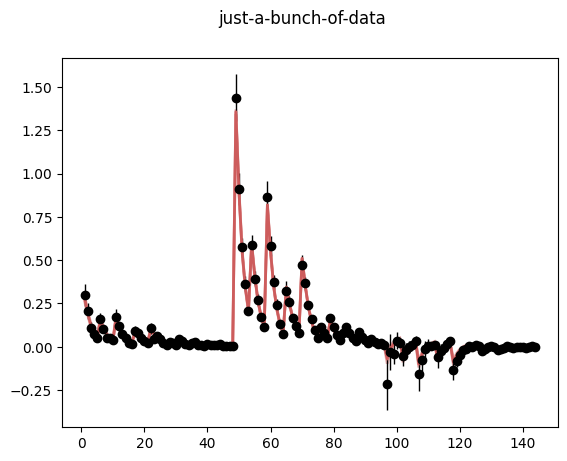

In [58]:
fig = gplot.jbod(points=fitpoints, lines=[th2], bands=[th2])

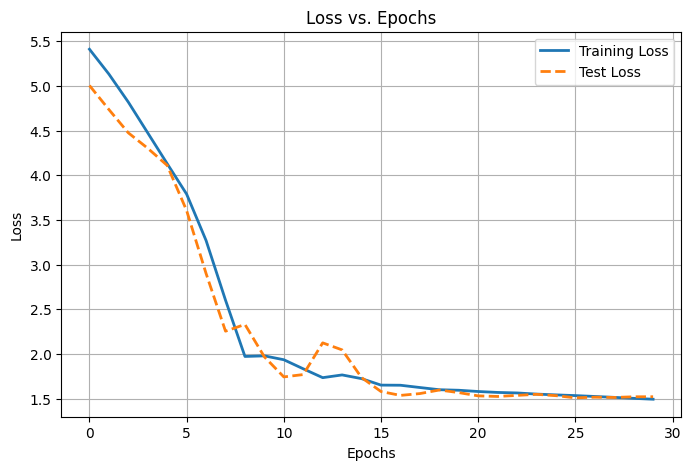

In [59]:
# Plot the results:
plt.figure(figsize=(8, 5))
plt.plot(f.history, label="Training Loss",linewidth=2.0)
plt.plot(f.test_history, label="Test Loss", linestyle="dashed",linewidth=2.0)
plt.xlabel("Epochs") #Epochs in nbatch length
plt.ylabel("Loss")
plt.title("Loss vs. Epochs")
plt.legend()
plt.grid()
plt.show()

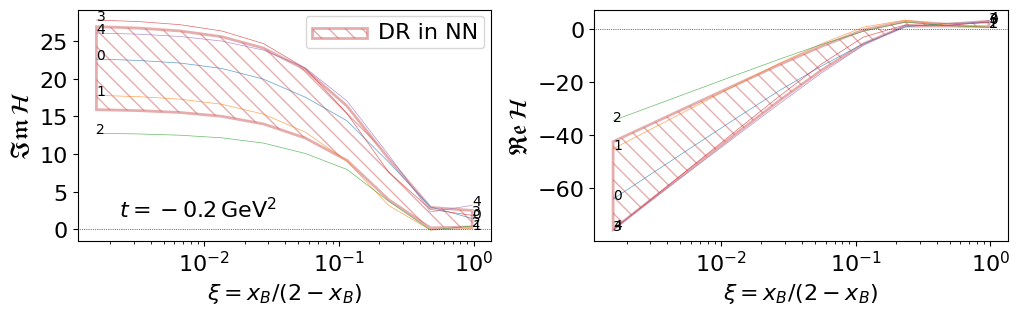

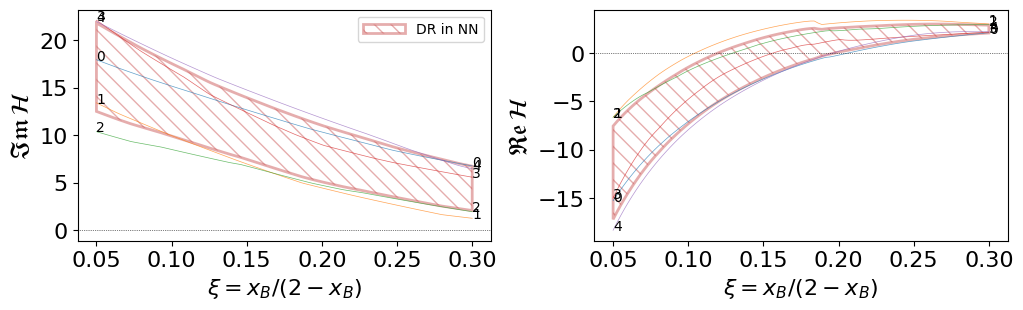

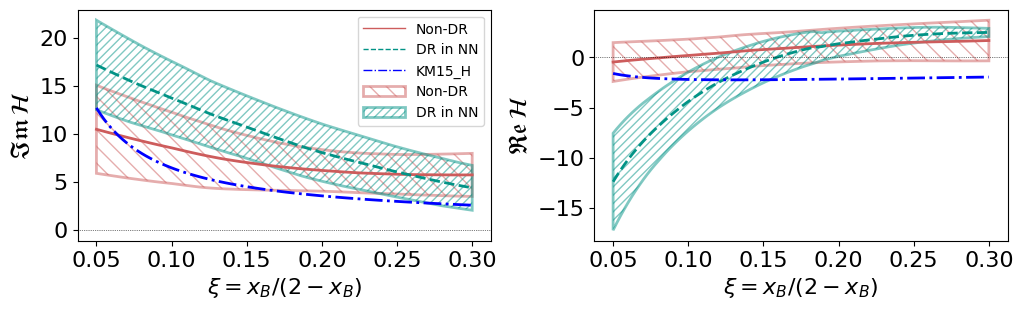

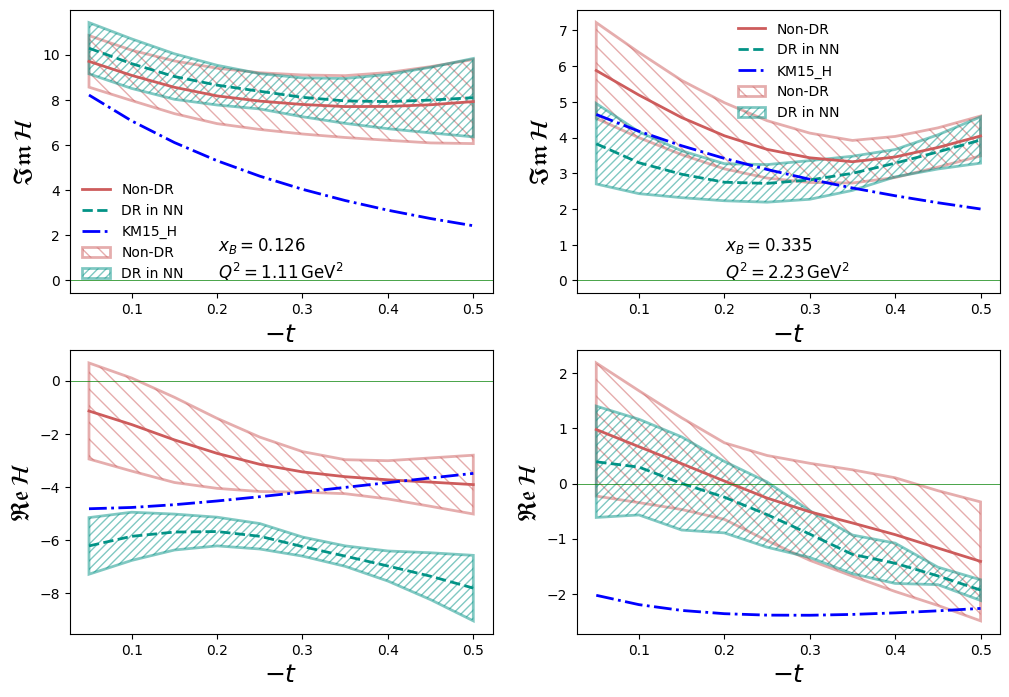

In [60]:
th.name = "Non-DR"
th2.name = "DR in NN"
fig = gplot.CFF3log(cffs=['ImH', 'ReH'],  mesh=th2, bands=[th2], tval=-0.2)
fig = gplot.CFF3(cffs=['ImH', 'ReH'],  mesh=th2, bands=[th2])
fig = gplot.CFF3(cffs=['ImH', 'ReH'],  lines=[th, th2, th_KM15_H], bands=[th, th2])
fig = gplot.CFFt(cffs=['ImH', 'ReH'],  lines=[th, th2, th_KM15_H], bands=[th, th2])

In [ ]:
import gc
import itertools
from sklearn.metrics import r2_score

def evaluate_model(th, dataset):
    truth = [pt.val for pt in dataset]
    preds = [th.predict(pt).item() for pt in dataset]
    return r2_score(truth, preds)

param_grid = {
    'nbatch': [10, 40, 80],
    'batchlen': [2, 5, 10],
    'lx_lambda': [0.0001, 0.001, 0.01],
    'regularization': ['L2', 'L1'],
}

combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

best_r2 = -float("inf")
best_params = None

for values in combinations:
    params = dict(zip(param_names, values))
    print(f"Trying: {params}")

    th, f = None, None  

    try:
        th = NNTest_DR(output_layer=['ImH', 'D'], use_adam=True)
        if hasattr(th, "net") and hasattr(th.net, "debug"):
            th.net.debug = False

        f = g.fitter.NeuralFitter(points, th, nnets=1, **params)
        f.fit()

        r2 = evaluate_model(th, points)
        print(f"R² = {r2:.4f}")

        if r2 > best_r2:
            best_r2 = r2
            best_params = params

    except Exception as e:
        print(f"Failed with {params}: {e}")

    finally:
        # Always clean up
        del th, f
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"\n Best parameters: {best_params}, R² = {best_r2:.4f}")

Trying: {'nbatch': 10, 'batchlen': 2, 'lx_lambda': 0.0001, 'regularization': 'L2'}

Epoch   2: train error = 6.4431 test error = 6.8578 -
Epoch   4: train error = 5.6902 test error = 6.4487 -
Epoch   6: train error = 5.0417 test error = 5.7582 -
Epoch   8: train error = 4.4015 test error = 5.2054 -
Epoch  10: train error = 3.8591 test error = 5.1947 -
Epoch  12: train error = 3.7439 test error = 5.1213 -
Epoch  14: train error = 3.6304 test error = 4.9427 -
Epoch  16: train error = 3.5174 test error = 4.8539 -
Epoch  18: train error = 3.4275 test error = 4.8147 -
Epoch  20: train error = 3.3324 test error = 4.8430 +Net 0 --> test_err = 4.814675925375797
R² = 0.0206
Trying: {'nbatch': 10, 'batchlen': 2, 'lx_lambda': 0.0001, 'regularization': 'L1'}

Epoch   2: train error = 8.1892 test error = 3.5499 -
Epoch   4: train error = 6.7145 test error = 3.5102 -
Epoch   6: train error = 5.7043 test error = 3.1730 -
Epoch   8: train error = 5.1229 test error = 3.2254 +
Epoch  10: train error = 4

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10441b310>>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/gepard-env-NNP/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 



Epoch  12: train error = 4.0768 test error = 3.5602 -
Epoch  14: train error = 4.0041 test error = 3.7377 +

## Test with 4 CFFs

In [ ]:
import torch.nn as nn
class CustomNetwork_4(nn.Module):
    def __init__(self):
        super(CustomNetwork_4, self).__init__()

        # Define the layers for the network
        self.n1 = nn.Linear(3, 23)  # 2 input features, 7 hidden units
        self.n2 = nn.Linear(23, 37)  # 7 hidden units, 7 hidden units
        self.n3 = nn.Linear(37, 2)  # 7 hidden units, 2 output features
        
        self.n1p = nn.Linear(1, 7)  # 2 input features, 7 hidden units
        self.n2p = nn.Linear(7, 5)  # 7 hidden units, 7 hidden units
        self.n3p = nn.Linear(5, 1)  # 7 hidden units, 2 output features

    def forward(self, x):
        
       
        x0 = x
        
        # Build Im network
        x = torch.relu(self.n1(x0))
        x = torch.relu(self.n2(x))
        output1 = self.n3(x)
        
        # Build D network
        # build the input tensor
        x0_1 = torch.cat((x0[:,1].unsqueeze(1),), dim=0)
       
        x2 = torch.relu(self.n1p(x0_1))
        x2 = torch.relu(self.n2p(x2))
        output2 = self.n3p(x2)
        
        #concatenate outputs
        output = torch.cat((output1, output2), dim=1)
       
        return output 

In [ ]:
class NNTest_DR_4(g.model.NeuralModel_DR, g.eff.DipoleEFF, g.dvcs.BM10tw2, g.cff.DispersionCFF):
    
    def build_net(self):
        '''Overriding the default architecture and optimizer'''
        nn_model = CustomNetwork_4()
        optimizer = torch.optim.Rprop(nn_model.parameters(),
                lr=0.05) # lr=0.01
        return nn_model, optimizer
    
    def subtraction(self, pt): #This should use the NN, the real part will be calculated by the CFF_Dispersion methods
        """Subtraction constant."""
        #print("I am here in D")
        xi = pt.xB / (2 - pt.xB)
        #refer to the location of D in output layer (defined in the next cell)
        return self.cffs(2, pt, xi)
    
    def ImH(self, pt, xi=0) -> float:
        """Return Im(CFF H) for kinematic point."""
        #refer to the location of Im H in output layer (defined in the next cell)
        return self.cffs(0, pt, xi)
    
    def ImE(self, pt, xi=0):
        """Return Im(CFF E) for kinematic point."""
        return self.cffs(1, pt, xi)
    
    def ImHt(self, pt, xi=0):
        """Return Im(CFF Ht) for kinematic point."""
        return self.zero(pt)
    
    def ImEt(self, pt, xi=0):
        """Return Im(CFF Et) for kinematic point."""
        return self.zero(pt)

In [ ]:
th3 = NNTest_DR_4(output_layer=['ImH', 'ImE', 'D'], q2in=True)

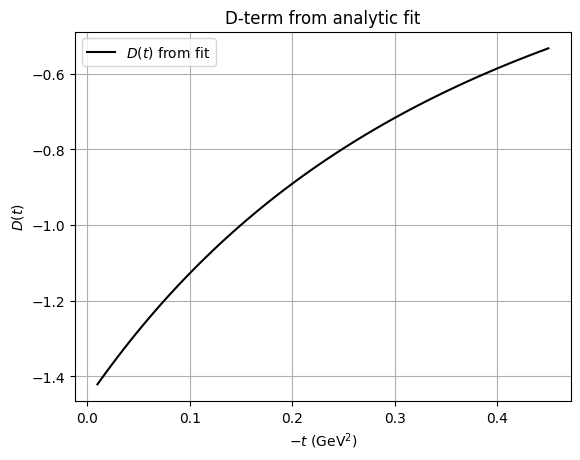

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
D0 = -1.46  # NEGATIVE D0 for comparison
M2 = 1.02
alpha = 2.76

# t values
t_vals = np.linspace(0.01, 0.45, 100)
D_vals = D0 * (1 + t_vals / M2) ** (-alpha)

# Plot
plt.figure()
plt.plot(t_vals, D_vals, label=r"$D(t)$ from fit", color='black')
plt.xlabel(r"$-t$ (GeV$^2$)")
plt.ylabel(r"$D(t)$")
plt.title("D-term from analytic fit")
plt.grid(True)
plt.legend()
plt.show()


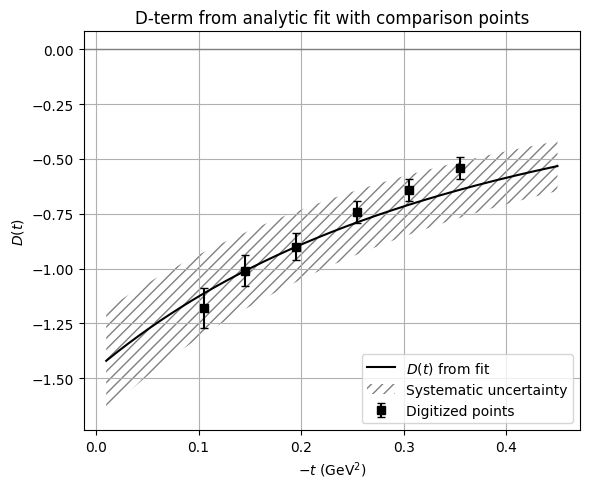

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Fit parameters and uncertainties
D0 = -1.46
D0_err = 0.24
M2 = 1.02
M2_err = 0.13
alpha = 2.76
alpha_err = 0.23

# t values
t_vals = np.linspace(0.01, 0.45, 300)
factor = (1 + (t_vals) / M2)
D_central = D0 * factor ** (-alpha)

# Error propagation
dD_dD0 = factor ** (-alpha)
dD_dM2 = D0 * alpha * factor ** (-alpha - 1) * (-t_vals / (M2**2))
dD_dalpha = -D0 * factor ** (-alpha) * np.log(factor)
D_err = np.sqrt((dD_dD0 * D0_err)**2 + (dD_dM2 * M2_err)**2 + (dD_dalpha * alpha_err)**2)

# Digitized comparison points
comparison_points = np.array([
    [0.105, -1.18, 0.09],
    [0.145, -1.01, 0.07],
    [0.195, -0.90, 0.06],
    [0.255, -0.74, 0.05],
    [0.305, -0.64, 0.05],
    [0.355, -0.54, 0.05]
])

t_comp = comparison_points[:, 0]
D_comp = comparison_points[:, 1]
D_err_comp = comparison_points[:, 2]

# Plot
plt.figure(figsize=(6,5))
plt.plot(t_vals, D_central, color='black', label=r"$D(t)$ from fit")
plt.fill_between(t_vals, D_central - D_err, D_central + D_err, 
                 hatch='///', facecolor='none', edgecolor='gray', linewidth=0.0,
                 label='Systematic uncertainty')
plt.errorbar(t_comp, D_comp, yerr=D_err_comp, fmt='s', color='black', 
             label='Digitized points', capsize=3)

plt.axhline(0, color='gray', linewidth=1)
plt.xlabel(r"$-t$ (GeV$^2$)")
plt.ylabel(r"$D(t)$")
plt.title(r"D-term from analytic fit with comparison points")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
